# Multi-Step Water Inflow Forecasting - EDA & Feature Engineering

Monthly water inflow forecasting for hydroelectric power plant operations. Goal: explore temporal structure, engineer features for regression models.

| Column | Description |
|--------|-------------|
| `Year` | Calendar year (1999-2022) |
| `Month` | Calendar month (1-12) |
| `Value` | Monthly water inflow measurement (volumetric units) |

**281 monthly observations**, January 1999 – May 2022.

---

## 2. Time Series Fundamentals

A time series can be decomposed into trend, seasonal, and residual components. We test stationarity (ADF/KPSS) and use ACF/PACF to identify optimal lag orders for modeling.

---

## 3. Setup and Data Loading

In [1]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from statsmodels.tsa.seasonal import STL, seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import os
import warnings
warnings.filterwarnings('ignore')

# Plot styling
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['figure.dpi'] = 100

# Consistent color palette
PALETTE = sns.color_palette('viridis', 24)
PRIMARY_COLOR = '#2C73D2'
SECONDARY_COLOR = '#FF6B6B'
ACCENT_COLOR = '#FFA94D'

# Ensure figures directory exists
FIGURES_DIR = '../figures/'
os.makedirs(FIGURES_DIR, exist_ok=True)

print('Setup complete. Libraries loaded successfully.')

Setup complete. Libraries loaded successfully.


In [2]:
# Load data
data_path = '../data/multistep_regression.csv'
df = pd.read_csv(data_path)

# Create proper datetime index
df['Date'] = pd.to_datetime(df[['Year', 'Month']].assign(Day=1))
df = df.set_index('Date').sort_index()
df.rename(columns={'Value': 'inflow'}, inplace=True)

# Set frequency explicitly
df.index.freq = 'MS'

print(f"Dataset shape: {df.shape}")
print(f"Date range: {df.index.min().strftime('%Y-%m-%d')} to {df.index.max().strftime('%Y-%m-%d')}")
print(f"Number of complete years: {df.index.year.nunique()}")
print(f"Missing values: {df['inflow'].isnull().sum()}")
print(f"\n{'='*50}")
print(f"Basic Statistics:")
print(f"{'='*50}")
df['inflow'].describe().to_frame().T

Dataset shape: (281, 3)
Date range: 1999-01-01 to 2022-05-01
Number of complete years: 24
Missing values: 0

Basic Statistics:


,count,mean,std,min,25%,50%,75%,max
inflow,281.0,33.195956,25.893953,3.474676,15.062259,23.753365,41.247543,139.154873


In [3]:
# Quick data inspection
print("First 12 rows (first full year):")
print(df.head(12).to_string())
print(f"\nData types:\n{df.dtypes}")
print(f"\nIndex type: {type(df.index)}")
print(f"Index freq: {df.index.freq}")

First 12 rows (first full year):
            Year  Month     inflow
Date                              
1999-01-01  1999      1  40.575599
1999-02-01  1999      2  65.182165
1999-03-01  1999      3  63.089448
1999-04-01  1999      4  81.853452
1999-05-01  1999      5  48.081737
1999-06-01  1999      6  24.487741
1999-07-01  1999      7  12.416174
1999-08-01  1999      8   7.119303
1999-09-01  1999      9  11.749033
1999-10-01  1999     10  15.605411
1999-11-01  1999     11  14.388636
1999-12-01  1999     12  16.142621

Data types:
Year        int64
Month       int64
inflow    float64
dtype: object

Index type: <class 'pandas.DatetimeIndex'>
Index freq: <MonthBegin>


---

## 4. Exploratory Data Analysis

### 4.1 Full Time Series Overview

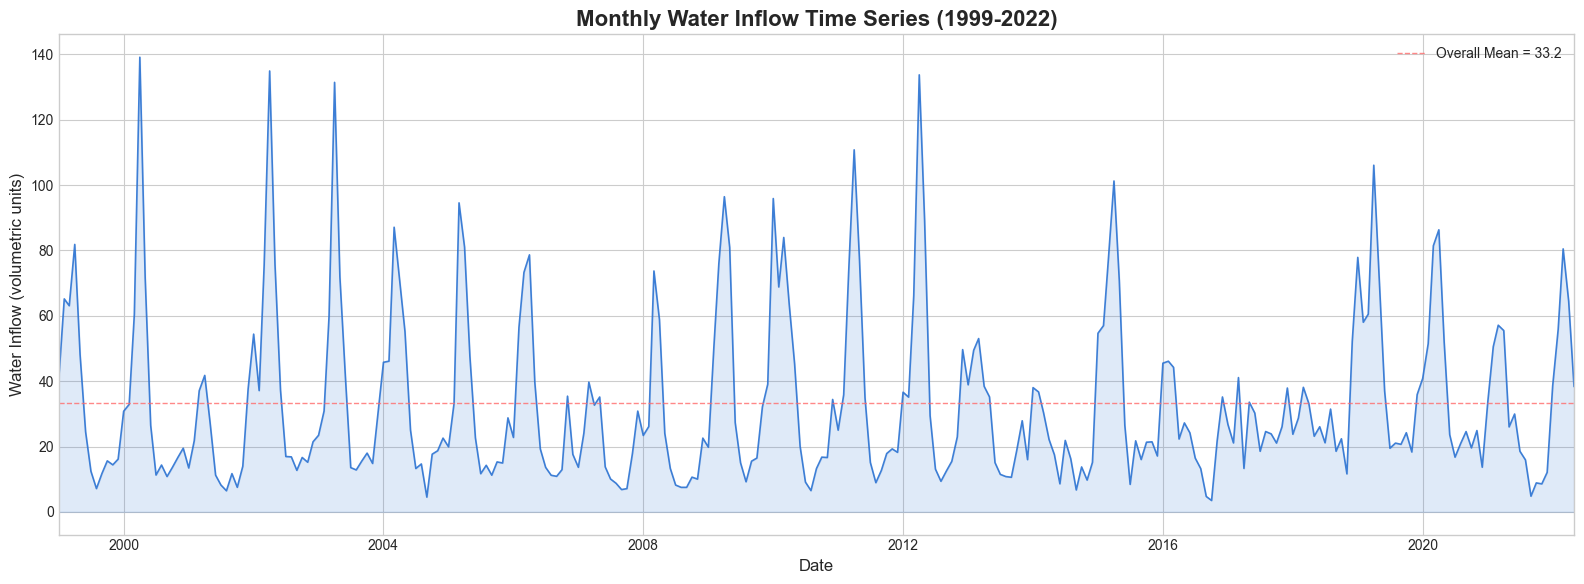

Observation: Clear seasonal pattern with peaks recurring annually (spring months). The amplitude of peaks varies considerably across years.


In [4]:
# 4.1 Full Time Series Plot (1999-2022)
fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(df.index, df['inflow'], color=PRIMARY_COLOR, linewidth=1.2, alpha=0.9)
ax.fill_between(df.index, df['inflow'], alpha=0.15, color=PRIMARY_COLOR)

# Add overall mean line
mean_val = df['inflow'].mean()
ax.axhline(y=mean_val, color=SECONDARY_COLOR, linestyle='--', linewidth=1, 
           label=f'Overall Mean = {mean_val:.1f}', alpha=0.8)

ax.set_title('Monthly Water Inflow Time Series (1999-2022)', fontsize=16, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Water Inflow (volumetric units)')
ax.legend(loc='upper right')
ax.set_xlim(df.index.min(), df.index.max())

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}c2_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()
print('Observation: Clear seasonal pattern with peaks recurring annually (spring months). '
      'The amplitude of peaks varies considerably across years.')

### 4.2 Yearly Overlay Plot

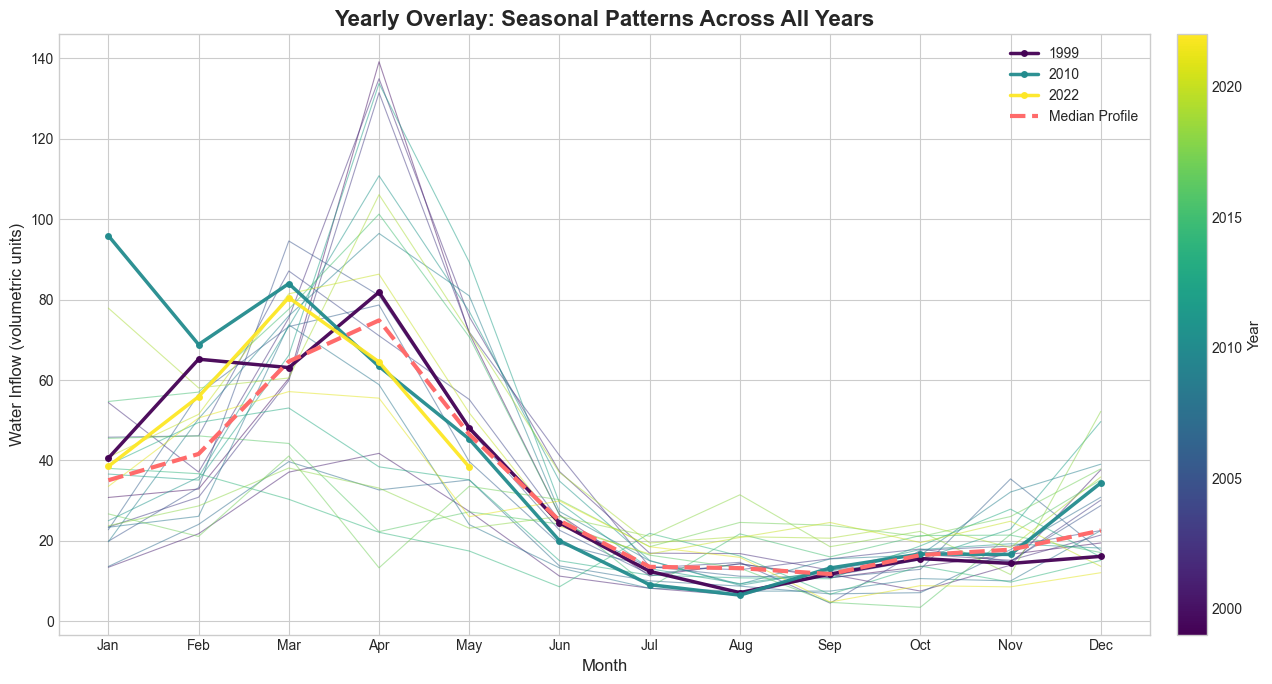

Observation: All years follow a similar seasonal shape -- peak in March-April (spring snowmelt),
trough in July-September (dry season). The peak amplitude varies substantially across years.


In [5]:
# 4.2 Yearly Overlay Plot
fig, ax = plt.subplots(figsize=(14, 7))

years = df['Year'].unique()
cmap = plt.cm.viridis(np.linspace(0, 1, len(years)))
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

for i, year in enumerate(years):
    yearly_data = df[df['Year'] == year]
    months = yearly_data['Month'].values
    values = yearly_data['inflow'].values
    
    # Highlight first, last, and specific years
    if year in [1999, 2010, 2022]:
        ax.plot(months, values, color=cmap[i], linewidth=2.5, alpha=0.95,
                label=str(year), marker='o', markersize=4, zorder=5)
    else:
        ax.plot(months, values, color=cmap[i], linewidth=0.8, alpha=0.5)

# Add median profile
monthly_median = df.groupby('Month')['inflow'].median()
ax.plot(monthly_median.index, monthly_median.values, color=SECONDARY_COLOR,
        linewidth=3, linestyle='--', label='Median Profile', zorder=10)

ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_labels)
ax.set_title('Yearly Overlay: Seasonal Patterns Across All Years', fontsize=16, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Water Inflow (volumetric units)')
ax.legend(loc='upper right', framealpha=0.9)

# Add colorbar to show year progression
sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(vmin=years.min(), vmax=years.max()))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label('Year', fontsize=11)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}c2_yearly_overlay.png', dpi=150, bbox_inches='tight')
plt.show()
print('Observation: All years follow a similar seasonal shape -- peak in March-April (spring snowmelt),\n'
      'trough in July-September (dry season). The peak amplitude varies substantially across years.')

### 4.3 Monthly Box Plot

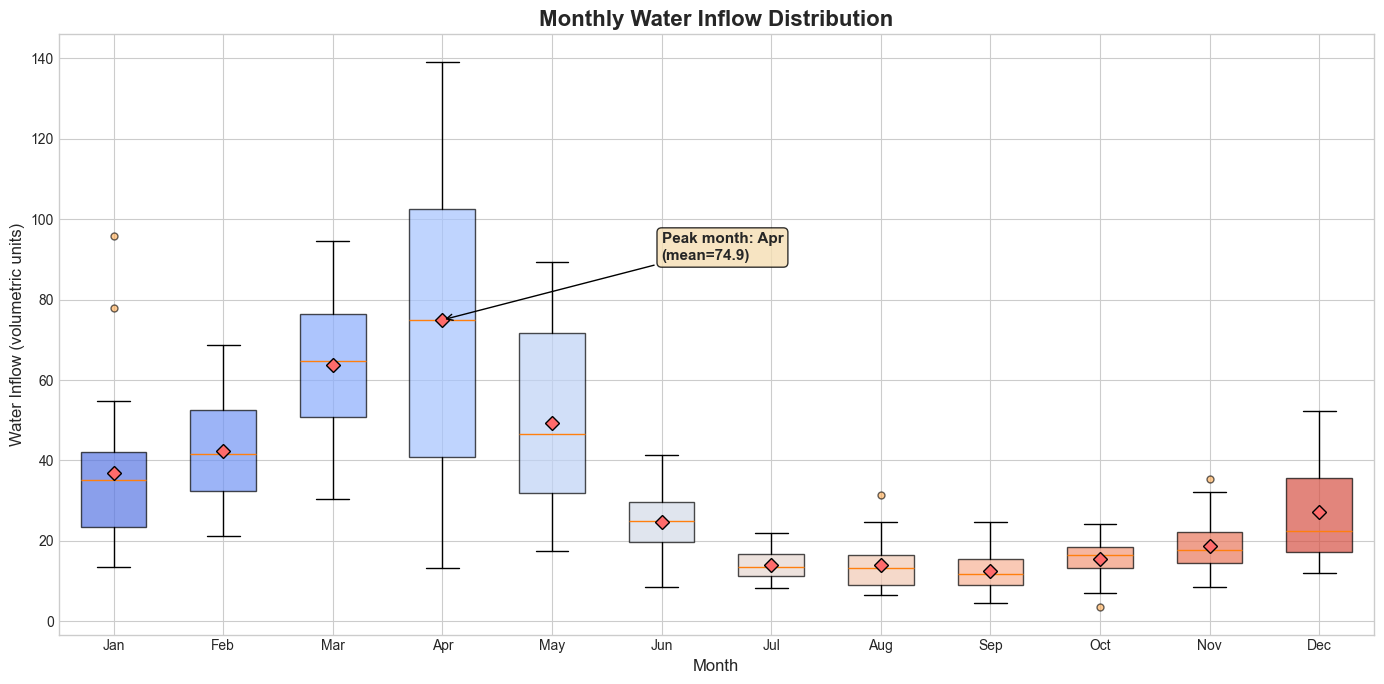

Monthly Mean Inflow:
  Jan:   36.8  (std:  19.4)
  Feb:   42.5  (std:  14.0)
  Mar:   63.7  (std:  18.0)
  Apr:   74.9  (std:  38.6)
  May:   49.4  (std:  21.7)
  Jun:   24.7  (std:   8.6)
  Jul:   14.1  (std:   4.1)
  Aug:   14.1  (std:   6.4)
  Sep:   12.5  (std:   5.6)
  Oct:   15.4  (std:   5.2)
  Nov:   18.8  (std:   7.0)
  Dec:   27.1  (std:  11.5)


In [6]:
# 4.3 Monthly Box Plot
fig, ax = plt.subplots(figsize=(14, 7))

month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

box_data = [df[df['Month'] == m]['inflow'].values for m in range(1, 13)]

bp = ax.boxplot(box_data, patch_artist=True, labels=month_labels,
                widths=0.6, showmeans=True,
                meanprops=dict(marker='D', markeredgecolor='black',
                              markerfacecolor=SECONDARY_COLOR, markersize=7),
                flierprops=dict(marker='o', markerfacecolor=ACCENT_COLOR,
                               markersize=5, alpha=0.6))

# Color boxes with gradient
colors = plt.cm.coolwarm(np.linspace(0.1, 0.9, 12))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_title('Monthly Water Inflow Distribution', fontsize=16, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Water Inflow (volumetric units)')

# Add annotation for peak month
monthly_means = df.groupby('Month')['inflow'].mean()
peak_month = monthly_means.idxmax()
ax.annotate(f'Peak month: {month_labels[peak_month-1]}\n(mean={monthly_means[peak_month]:.1f})',
            xy=(peak_month, monthly_means[peak_month]),
            xytext=(peak_month + 2, monthly_means[peak_month] + 15),
            arrowprops=dict(arrowstyle='->', color='black'),
            fontsize=11, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}c2_monthly_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

print('Monthly Mean Inflow:')
for m in range(1, 13):
    print(f'  {month_labels[m-1]:>3s}: {monthly_means[m]:6.1f}  (std: {df[df["Month"]==m]["inflow"].std():5.1f})')

### 4.4 Seasonal Decomposition (STL)

STL decomposes the series into trend, seasonal, and residual components using LOESS smoothing.

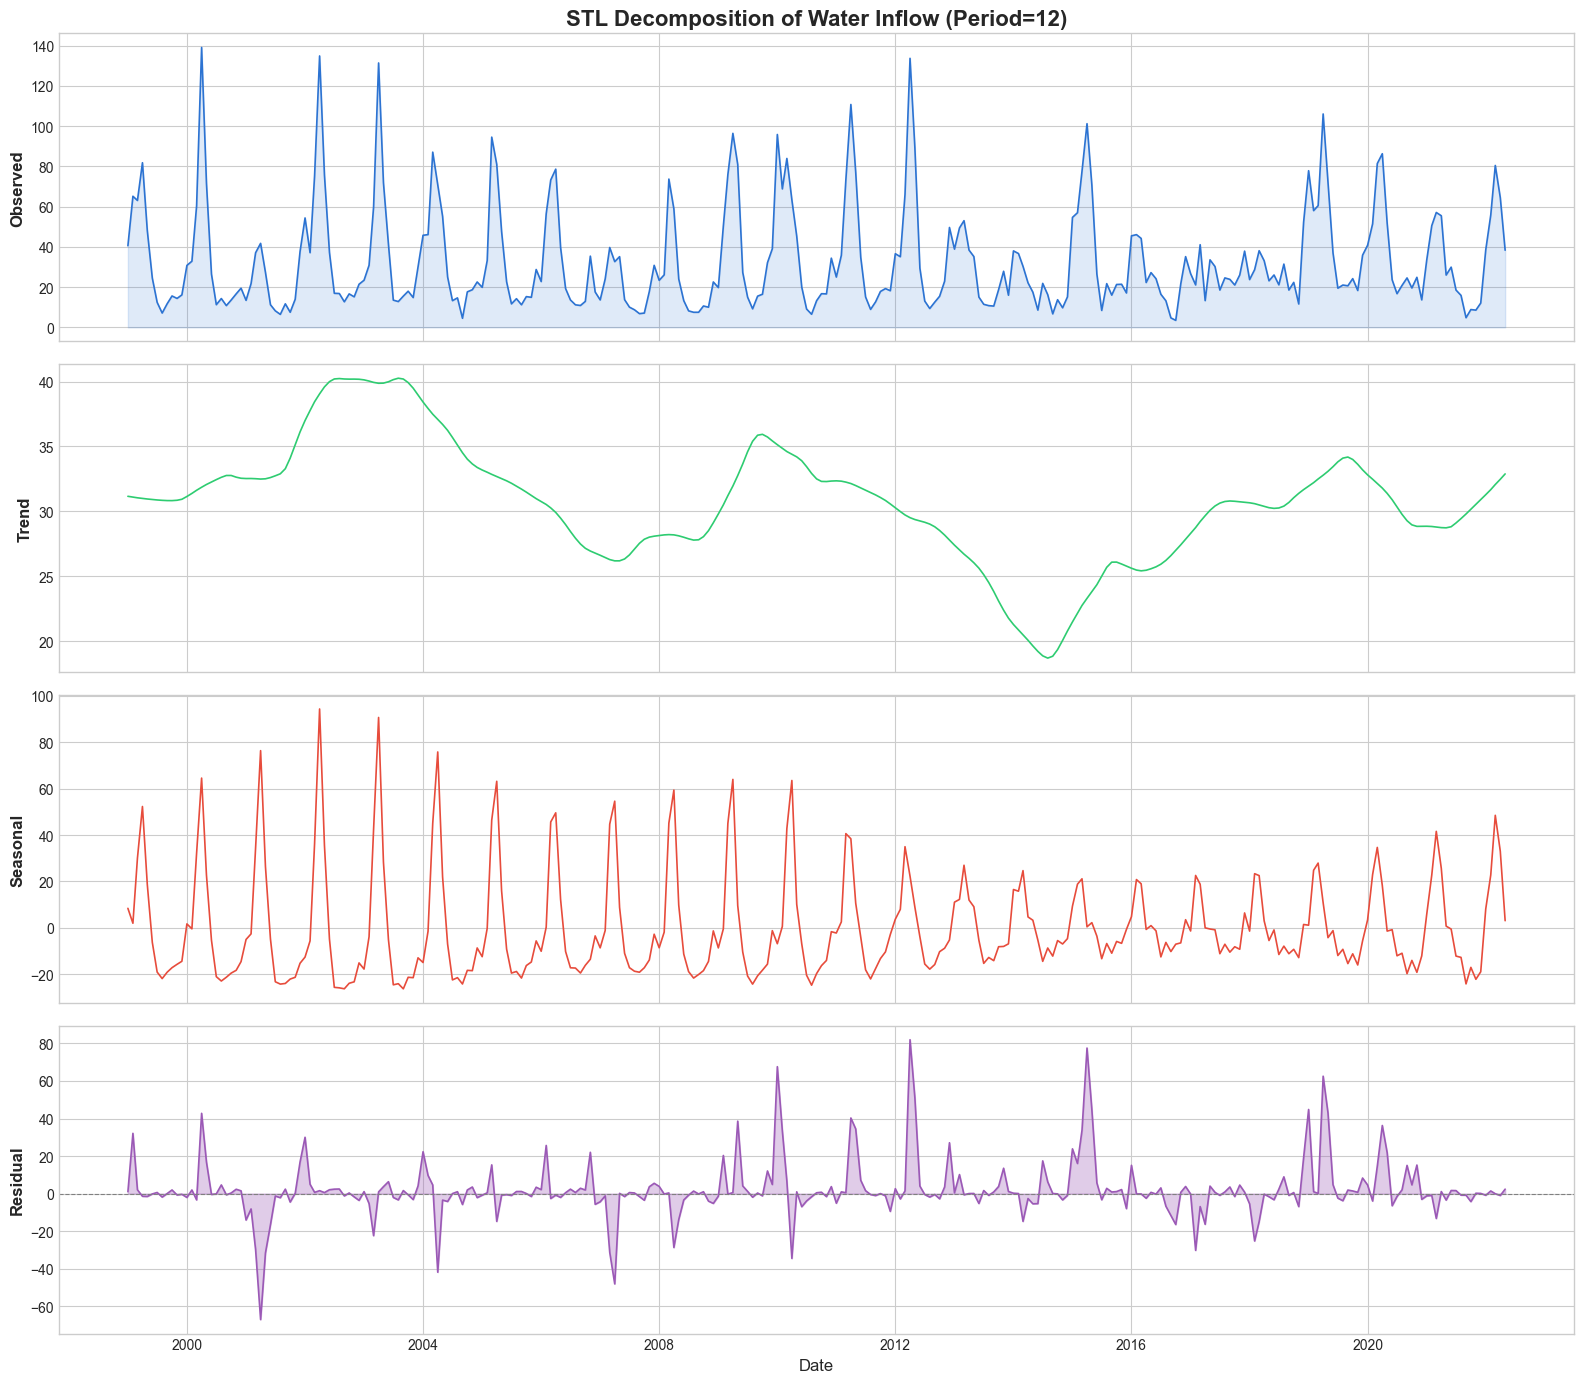

Component Strength Analysis:
  Seasonal strength: 0.634 (1.0 = perfectly seasonal)
  Trend strength:    0.069 (1.0 = perfectly trending)

Interpretation:
  - Seasonality is the dominant component in this time series.
  - The trend component shows moderate long-term changes.
  - Residuals capture year-to-year variability not explained by the regular pattern.


In [7]:
# 4.4 STL Decomposition
stl = STL(df['inflow'], period=12, robust=True)
stl_result = stl.fit()

fig, axes = plt.subplots(4, 1, figsize=(16, 14), sharex=True)

components = [
    ('Observed', stl_result.observed, PRIMARY_COLOR),
    ('Trend', stl_result.trend, '#2ECC71'),
    ('Seasonal', stl_result.seasonal, '#E74C3C'),
    ('Residual', stl_result.resid, '#9B59B6')
]

for ax, (title, data, color) in zip(axes, components):
    ax.plot(data.index, data.values, color=color, linewidth=1.2)
    if title == 'Residual':
        ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.8)
        ax.fill_between(data.index, data.values, alpha=0.3, color=color)
    elif title == 'Observed':
        ax.fill_between(data.index, data.values, alpha=0.15, color=color)
    ax.set_ylabel(title, fontsize=12, fontweight='bold')
    ax.tick_params(axis='both', labelsize=10)

axes[0].set_title('STL Decomposition of Water Inflow (Period=12)', fontsize=16, fontweight='bold')
axes[-1].set_xlabel('Date')

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}c2_seasonal_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

# Quantify component strength
total_var = np.var(stl_result.observed)
seasonal_strength = 1 - np.var(stl_result.resid) / np.var(stl_result.seasonal + stl_result.resid)
trend_strength = 1 - np.var(stl_result.resid) / np.var(stl_result.trend + stl_result.resid)

print(f'Component Strength Analysis:')
print(f'  Seasonal strength: {seasonal_strength:.3f} (1.0 = perfectly seasonal)')
print(f'  Trend strength:    {trend_strength:.3f} (1.0 = perfectly trending)')
print(f'\nInterpretation:')
print(f'  - Seasonality is the dominant component in this time series.')
print(f'  - The trend component shows moderate long-term changes.')
print(f'  - Residuals capture year-to-year variability not explained by the regular pattern.')

### 4.5 Autocorrelation Analysis (ACF and PACF)

ACF measures correlation at each lag; PACF measures direct correlation after removing intermediate effects.

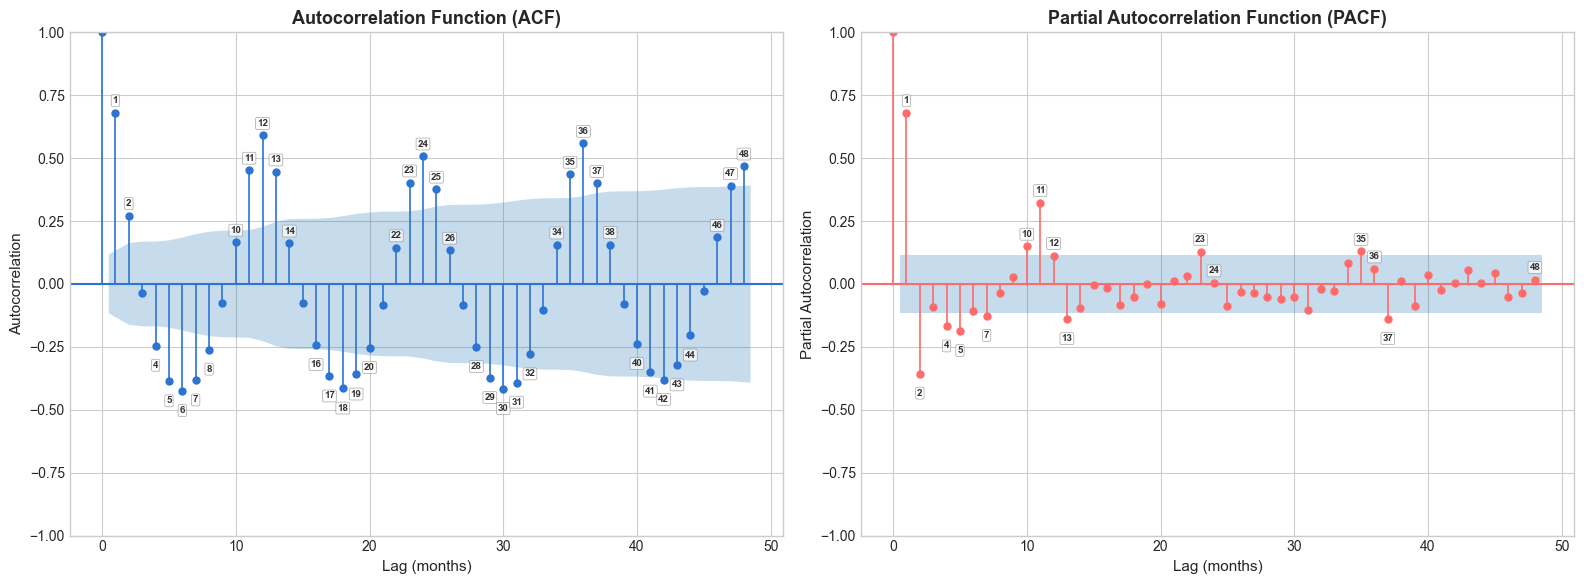

In [8]:
# 4.5 ACF and PACF Plots (with lag annotations)
from statsmodels.tsa.stattools import acf as acf_func

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ACF
plot_acf(df['inflow'], lags=48, ax=axes[0], color=PRIMARY_COLOR,
         vlines_kwargs={'color': PRIMARY_COLOR, 'linewidth': 1.2},
         title='')
axes[0].set_title('Autocorrelation Function (ACF)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Lag (months)', fontsize=11)
axes[0].set_ylabel('Autocorrelation', fontsize=11)

# ACF - annotate significant lags
n = len(df['inflow'])
conf = 1.96 / np.sqrt(n)
acf_vals = acf_func(df['inflow'], nlags=48)

for lag_i in range(1, 49):
    val = acf_vals[lag_i]
    is_significant = abs(val) > conf
    is_milestone = lag_i % 12 == 0
    if is_significant or is_milestone:
        offset_y = 0.03 if val >= 0 else -0.06
        axes[0].text(lag_i, val + offset_y, str(lag_i),
                     ha='center', va='bottom' if val >= 0 else 'top',
                     fontsize=7, fontweight='bold', color='#333333',
                     bbox=dict(boxstyle='round,pad=0.15', facecolor='white',
                               edgecolor='gray', alpha=0.7, linewidth=0.5))

# PACF
plot_pacf(df['inflow'], lags=48, ax=axes[1], color=SECONDARY_COLOR,
          vlines_kwargs={'color': SECONDARY_COLOR, 'linewidth': 1.2},
          title='', method='ywm')
axes[1].set_title('Partial Autocorrelation Function (PACF)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Lag (months)', fontsize=11)
axes[1].set_ylabel('Partial Autocorrelation', fontsize=11)

# PACF - annotate significant lags
pacf_vals_48 = pacf(df['inflow'], nlags=48, method='ywm')
for lag_i in range(1, 49):
    val = pacf_vals_48[lag_i]
    is_significant = abs(val) > conf
    is_milestone = lag_i % 12 == 0
    if is_significant or is_milestone:
        offset_y = 0.03 if val >= 0 else -0.06
        axes[1].text(lag_i, val + offset_y, str(lag_i),
                     ha='center', va='bottom' if val >= 0 else 'top',
                     fontsize=7, fontweight='bold', color='#333333',
                     bbox=dict(boxstyle='round,pad=0.15', facecolor='white',
                               edgecolor='gray', alpha=0.7, linewidth=0.5))

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}c2_acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()

**ACF/PACF Interpretation:**

- **ACF**: Sinusoidal pattern with peaks at lags 12, 24, 36, 48 — strong 12-month seasonality. Slow decay indicates near-non-stationarity.
- **PACF**: Significant spikes at lags 1-3 and lag 12 — AR model with seasonal component appropriate.
- **Key lags**: 1, 2, 3, 6, 11, 12, 13, 24.

### 4.6 Stationarity Tests

We apply two complementary hypothesis tests to rigorously assess stationarity.

In [9]:
# 4.6 Stationarity Tests: ADF and KPSS
def run_stationarity_tests(series, series_name='Original'):
    """Run ADF and KPSS tests and return formatted results."""
    results = {}
    
    # ADF Test
    adf_stat, adf_p, adf_lags, adf_nobs, adf_crit, adf_icbest = adfuller(series.dropna(), autolag='AIC')
    results['ADF'] = {
        'Test Statistic': adf_stat,
        'p-value': adf_p,
        'Lags Used': adf_lags,
        'Critical 1%': adf_crit['1%'],
        'Critical 5%': adf_crit['5%'],
        'Critical 10%': adf_crit['10%'],
        'Stationary?': 'Yes' if adf_p < 0.05 else 'No'
    }
    
    # KPSS Test
    kpss_stat, kpss_p, kpss_lags, kpss_crit = kpss(series.dropna(), regression='c', nlags='auto')
    results['KPSS'] = {
        'Test Statistic': kpss_stat,
        'p-value': kpss_p,
        'Lags Used': kpss_lags,
        'Critical 1%': kpss_crit['1%'],
        'Critical 5%': kpss_crit['5%'],
        'Critical 10%': kpss_crit['10%'],
        'Stationary?': 'Yes' if kpss_p > 0.05 else 'No'
    }
    
    return results

# Run on original series
orig_results = run_stationarity_tests(df['inflow'], 'Original')

# Run on differenced series (d=1)
diff_results = run_stationarity_tests(df['inflow'].diff().dropna(), 'First Difference')

# Run on seasonally differenced series (D=1, s=12)
seasonal_diff = df['inflow'].diff(12).dropna()
sdiff_results = run_stationarity_tests(seasonal_diff, 'Seasonal Difference (lag=12)')

# Display results as formatted table
print('='*85)
print(f'{"STATIONARITY TEST RESULTS":^85}')
print('='*85)

for series_name, results in [('Original Series', orig_results), 
                              ('First Difference (d=1)', diff_results),
                              ('Seasonal Difference (D=1, s=12)', sdiff_results)]:
    print(f'\n--- {series_name} ---')
    print(f'{"Test":<8} {"Statistic":>12} {"p-value":>10} {"1%":>10} {"5%":>10} {"10%":>10} {"Stationary?":>13}')
    print('-'*75)
    for test_name, vals in results.items():
        print(f'{test_name:<8} {vals["Test Statistic"]:>12.4f} {vals["p-value"]:>10.4f} '
              f'{vals["Critical 1%"]:>10.4f} {vals["Critical 5%"]:>10.4f} '
              f'{vals["Critical 10%"]:>10.4f} {vals["Stationary?"]:>13}')

print(f'\n{"="*85}')
print('Interpretation:')
print('  ADF: H0 = series has unit root (non-stationary). Reject if p < 0.05.')
print('  KPSS: H0 = series is stationary. Reject if p < 0.05.')
print('  Both tests agreeing on stationarity/non-stationarity provides strong evidence.')

                              STATIONARITY TEST RESULTS                              

--- Original Series ---
Test        Statistic    p-value         1%         5%        10%   Stationary?
---------------------------------------------------------------------------
ADF           -3.7531     0.0034    -3.4551    -2.8724    -2.5726           Yes
KPSS           0.0316     0.1000     0.7390     0.4630     0.3470           Yes

--- First Difference (d=1) ---
Test        Statistic    p-value         1%         5%        10%   Stationary?
---------------------------------------------------------------------------
ADF          -13.2349     0.0000    -3.4549    -2.8723    -2.5725           Yes
KPSS           0.0549     0.1000     0.7390     0.4630     0.3470           Yes

--- Seasonal Difference (D=1, s=12) ---
Test        Statistic    p-value         1%         5%        10%   Stationary?
---------------------------------------------------------------------------
ADF           -5.3139     0.

### 4.7 Yearly Average Trend Analysis

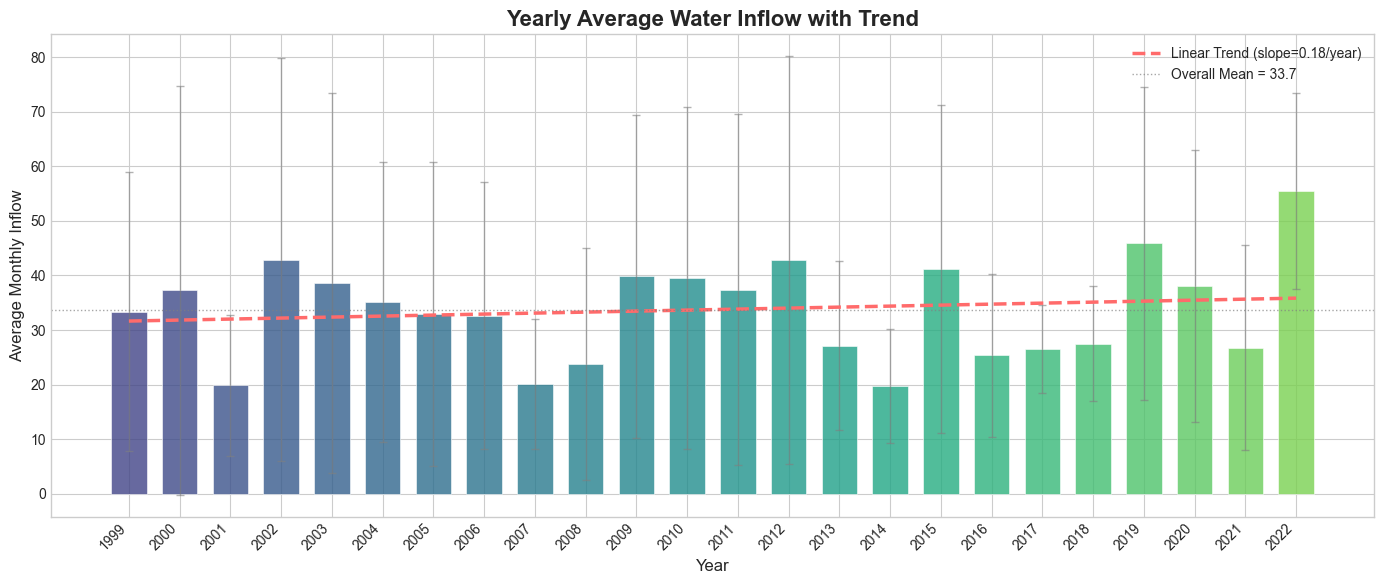

Trend slope: 0.183 units/year
Highest average year: 2022 (55.5)
Lowest average year:  2014 (19.7)


In [10]:
# 4.7 Yearly Average Trend Analysis
yearly_stats = df.groupby('Year')['inflow'].agg(['mean', 'std', 'min', 'max', 'median'])

fig, ax = plt.subplots(figsize=(14, 6))

# Bar plot for yearly means
bars = ax.bar(yearly_stats.index, yearly_stats['mean'], 
              color=plt.cm.viridis(np.linspace(0.2, 0.8, len(yearly_stats))),
              alpha=0.8, edgecolor='white', linewidth=0.5, width=0.7)

# Add error bars (std)
ax.errorbar(yearly_stats.index, yearly_stats['mean'], 
            yerr=yearly_stats['std'], fmt='none', ecolor='gray', 
            elinewidth=1, capsize=3, alpha=0.6)

# Trend line
z = np.polyfit(yearly_stats.index, yearly_stats['mean'], 1)
p = np.poly1d(z)
ax.plot(yearly_stats.index, p(yearly_stats.index), color=SECONDARY_COLOR, 
        linewidth=2.5, linestyle='--', label=f'Linear Trend (slope={z[0]:.2f}/year)')

# Overall mean
overall_mean = yearly_stats['mean'].mean()
ax.axhline(y=overall_mean, color='gray', linestyle=':', linewidth=1,
           label=f'Overall Mean = {overall_mean:.1f}', alpha=0.7)

ax.set_title('Yearly Average Water Inflow with Trend', fontsize=16, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Average Monthly Inflow')
ax.legend(loc='upper right')
ax.set_xticks(yearly_stats.index)
ax.set_xticklabels(yearly_stats.index, rotation=45, ha='right')

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}c2_yearly_trend.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Trend slope: {z[0]:.3f} units/year')
print(f'Highest average year: {yearly_stats["mean"].idxmax()} ({yearly_stats["mean"].max():.1f})')
print(f'Lowest average year:  {yearly_stats["mean"].idxmin()} ({yearly_stats["mean"].min():.1f})')

### 4.8 Distribution Analysis

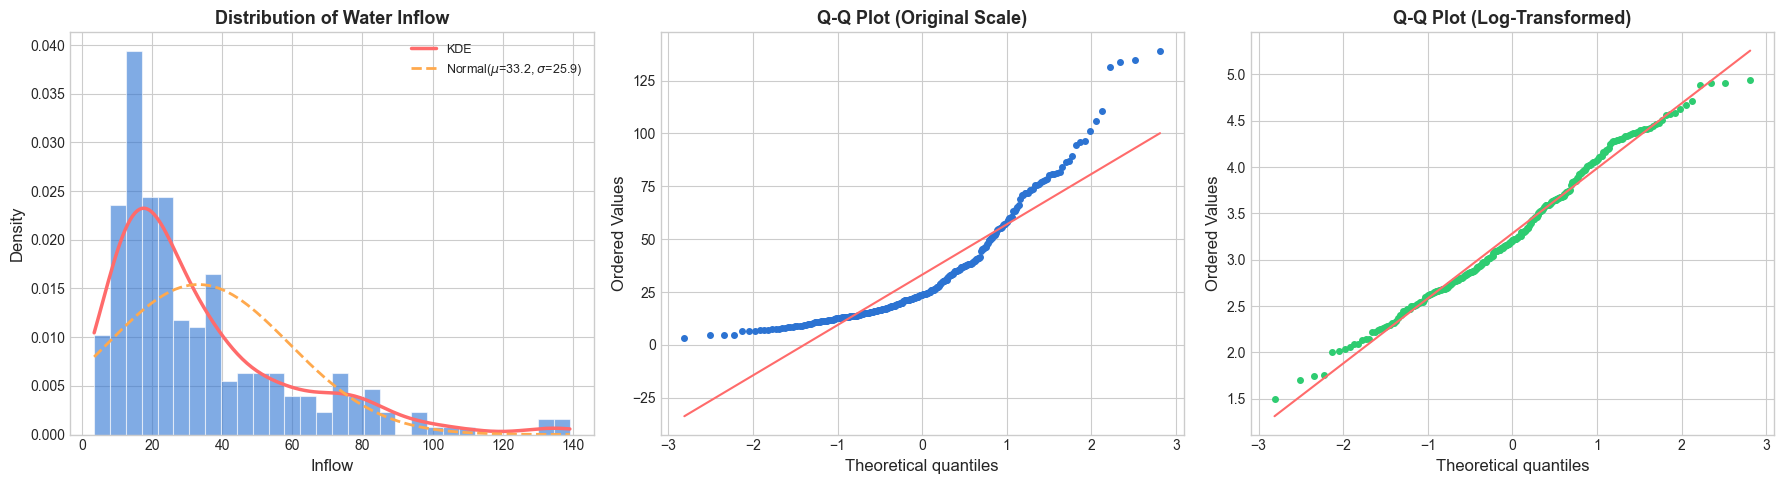

Distribution Diagnostics:
  Skewness:  1.601 (positive = right-skewed)
  Kurtosis:  2.642 (excess kurtosis; 0 = normal)
  Shapiro-Wilk (original):        W=0.8338, p=0.000000
  Shapiro-Wilk (log-transformed):  W=0.9875, p=0.015869

The distribution is right-skewed, which is typical for inflow data.
Log transformation improves normality -- consider log-transforming for models assuming Gaussian errors.


In [11]:
# 4.8 Distribution Analysis: Histogram + KDE + Q-Q Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram + KDE
axes[0].hist(df['inflow'], bins=30, density=True, alpha=0.6, color=PRIMARY_COLOR,
             edgecolor='white', linewidth=0.8)
x_kde = np.linspace(df['inflow'].min(), df['inflow'].max(), 200)
kde = stats.gaussian_kde(df['inflow'])
axes[0].plot(x_kde, kde(x_kde), color=SECONDARY_COLOR, linewidth=2.5, label='KDE')

# Normal distribution overlay
mu, sigma = df['inflow'].mean(), df['inflow'].std()
x_norm = np.linspace(df['inflow'].min(), df['inflow'].max(), 200)
axes[0].plot(x_norm, stats.norm.pdf(x_norm, mu, sigma), color=ACCENT_COLOR,
             linewidth=2, linestyle='--', label=f'Normal($\mu$={mu:.1f}, $\sigma$={sigma:.1f})')

axes[0].set_title('Distribution of Water Inflow', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Inflow')
axes[0].set_ylabel('Density')
axes[0].legend(fontsize=9)

# Q-Q Plot (Original)
stats.probplot(df['inflow'], dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot (Original Scale)', fontsize=13, fontweight='bold')
axes[1].get_lines()[0].set_markerfacecolor(PRIMARY_COLOR)
axes[1].get_lines()[0].set_markeredgecolor(PRIMARY_COLOR)
axes[1].get_lines()[0].set_markersize(4)
axes[1].get_lines()[1].set_color(SECONDARY_COLOR)

# Q-Q Plot (Log-transformed)
log_inflow = np.log1p(df['inflow'])
stats.probplot(log_inflow, dist='norm', plot=axes[2])
axes[2].set_title('Q-Q Plot (Log-Transformed)', fontsize=13, fontweight='bold')
axes[2].get_lines()[0].set_markerfacecolor('#2ECC71')
axes[2].get_lines()[0].set_markeredgecolor('#2ECC71')
axes[2].get_lines()[0].set_markersize(4)
axes[2].get_lines()[1].set_color(SECONDARY_COLOR)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}c2_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Normality tests
shapiro_stat, shapiro_p = stats.shapiro(df['inflow'])
shapiro_log_stat, shapiro_log_p = stats.shapiro(log_inflow)
skewness = df['inflow'].skew()
kurtosis = df['inflow'].kurtosis()

print(f'Distribution Diagnostics:')
print(f'  Skewness:  {skewness:.3f} (positive = right-skewed)')
print(f'  Kurtosis:  {kurtosis:.3f} (excess kurtosis; 0 = normal)')
print(f'  Shapiro-Wilk (original):        W={shapiro_stat:.4f}, p={shapiro_p:.6f}')
print(f'  Shapiro-Wilk (log-transformed):  W={shapiro_log_stat:.4f}, p={shapiro_log_p:.6f}')
print(f'\nThe distribution is right-skewed, which is typical for inflow data.')
print(f'Log transformation improves normality -- consider log-transforming for models assuming Gaussian errors.')

### 4.9 Heatmap: Month x Year Inflow Matrix

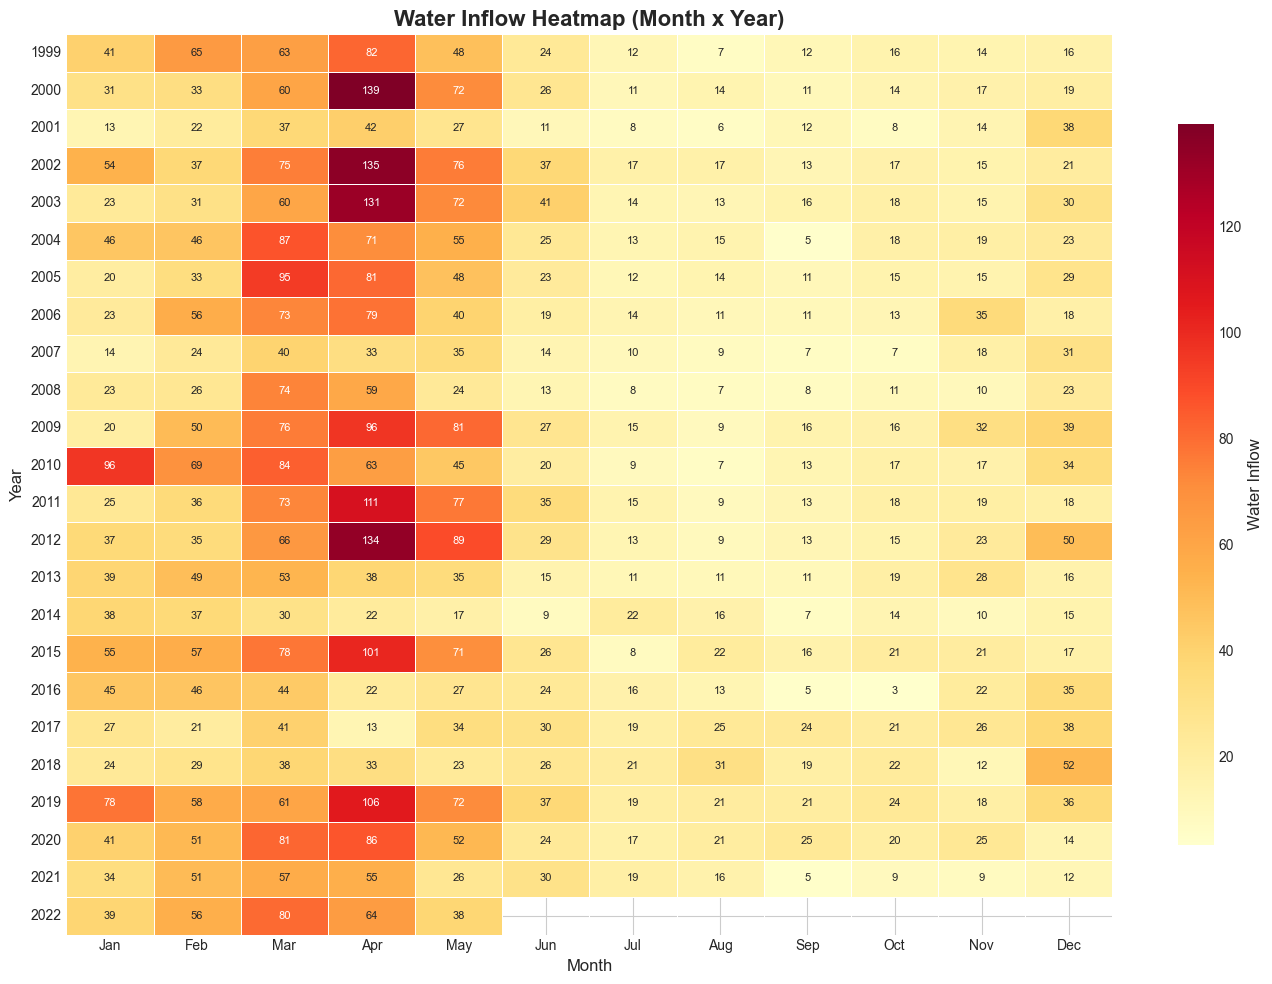

Heatmap Observations:
  - Spring months (Mar-Apr) consistently show the highest inflow values (darkest cells).
  - Summer months (Jul-Sep) are consistently the driest period.
  - Some years stand out: 2000 and 2003 had exceptionally high April peaks.
  - The 2022 data is partial (Jan-May only).


In [12]:
# 4.9 Heatmap: Month x Year Matrix
pivot_df = df.pivot_table(values='inflow', index='Year', columns='Month', aggfunc='mean')
pivot_df.columns = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                     'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

fig, ax = plt.subplots(figsize=(14, 10))

sns.heatmap(pivot_df, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Water Inflow', 'shrink': 0.8},
            ax=ax, annot_kws={'size': 8})

ax.set_title('Water Inflow Heatmap (Month x Year)', fontsize=16, fontweight='bold')
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Year', fontsize=12)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}c2_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('Heatmap Observations:')
print('  - Spring months (Mar-Apr) consistently show the highest inflow values (darkest cells).')
print('  - Summer months (Jul-Sep) are consistently the driest period.')
print('  - Some years stand out: 2000 and 2003 had exceptionally high April peaks.')
print('  - The 2022 data is partial (Jan-May only).')

---

## 5. Feature Engineering

Features for regression-based forecasting models (XGBoost, Random Forest, Ridge):

| Category | Features | Rationale |
|----------|----------|-----------|
| **Lag features** | lag_1, lag_2, lag_3, lag_6, lag_12, lag_24 | Autoregressive dependencies |
| **Rolling statistics** | Rolling mean, std, min, max (3, 6, 12 months) | Local trends/volatility |
| **Seasonal encoding** | sin(month), cos(month) | Cyclical month encoding |
| **Trend feature** | Linear time index | Long-term drift |
| **Difference features** | Month-over-month, year-over-year changes | Momentum and seasonal differences |
| **PACF-based selection** | Top significant PACF lags | Data-driven lag identification |

### 5.1 Lag Features

Lag features provide the model with historical context. We include lags at multiple horizons:
- **Short-term (1-3 months)**: Capture recent momentum and autoregressive effects.
- **Medium-term (6 months)**: Capture half-year dynamics (e.g., wet-to-dry transition).
- **Seasonal (12, 24 months)**: Capture annual and bi-annual patterns.

In [13]:
# 5.1 Lag Features
df_feat = df[['inflow', 'Year', 'Month']].copy()

lag_periods = [1, 2, 3, 6, 12, 24]
for lag in lag_periods:
    df_feat[f'lag_{lag}'] = df_feat['inflow'].shift(lag)

print(f'Lag features created: {[f"lag_{l}" for l in lag_periods]}')
print(f'\nLag feature preview (last 5 rows):')
lag_cols = [f'lag_{l}' for l in lag_periods]
df_feat[['inflow'] + lag_cols].tail().round(2)

Lag features created: ['lag_1', 'lag_2', 'lag_3', 'lag_6', 'lag_12', 'lag_24']

Lag feature preview (last 5 rows):


,inflow,lag_1,lag_2,lag_3,lag_6,lag_12,lag_24
Date,,,,,,,
2022-01-01,38.53,12.08,8.56,8.86,18.54,33.55,40.82
2022-02-01,55.86,38.53,12.08,8.56,15.90,50.57,51.46
2022-03-01,80.49,55.86,38.53,12.08,4.79,57.12,81.44
2022-04-01,64.48,80.49,55.86,38.53,8.86,55.49,86.33
2022-05-01,38.35,64.48,80.49,55.86,8.56,26.00,51.82


### 5.2 Rolling Statistics

Rolling (moving) statistics over different window sizes capture the local behavior of the series:
- **Rolling mean**: Local trend approximation.
- **Rolling std**: Local volatility / variability.
- **Rolling min/max**: Extreme value bounds in recent history.

In [14]:
# 5.2 Rolling Statistics
windows = [3, 6, 12]
for w in windows:
    df_feat[f'rolling_mean_{w}'] = df_feat['inflow'].shift(1).rolling(window=w).mean()
    df_feat[f'rolling_std_{w}'] = df_feat['inflow'].shift(1).rolling(window=w).std()
    df_feat[f'rolling_min_{w}'] = df_feat['inflow'].shift(1).rolling(window=w).min()
    df_feat[f'rolling_max_{w}'] = df_feat['inflow'].shift(1).rolling(window=w).max()

rolling_cols = [c for c in df_feat.columns if 'rolling' in c]
print(f'Rolling features created ({len(rolling_cols)} features):')
for w in windows:
    w_cols = [c for c in rolling_cols if c.endswith(f'_{w}')]
    print(f'  Window {w:>2d}: {w_cols}')

print(f'\nRolling feature preview (last 5 rows):')
df_feat[['inflow'] + [f'rolling_mean_{w}' for w in windows]].tail().round(2)

Rolling features created (12 features):
  Window  3: ['rolling_mean_3', 'rolling_std_3', 'rolling_min_3', 'rolling_max_3']
  Window  6: ['rolling_mean_6', 'rolling_std_6', 'rolling_min_6', 'rolling_max_6']
  Window 12: ['rolling_mean_12', 'rolling_std_12', 'rolling_min_12', 'rolling_max_12']

Rolling feature preview (last 5 rows):


,inflow,rolling_mean_3,rolling_mean_6,rolling_mean_12
Date,,,,
2022-01-01,38.53,9.83,11.45,26.78
2022-02-01,55.86,19.72,14.78,27.20
2022-03-01,80.49,35.49,21.45,27.64
2022-04-01,64.48,58.29,34.06,29.59
2022-05-01,38.35,66.95,43.33,30.34


### 5.3 Seasonal (Cyclical) Encoding

Sin/cos transforms preserve cyclical nature — December stays close to January in feature space.

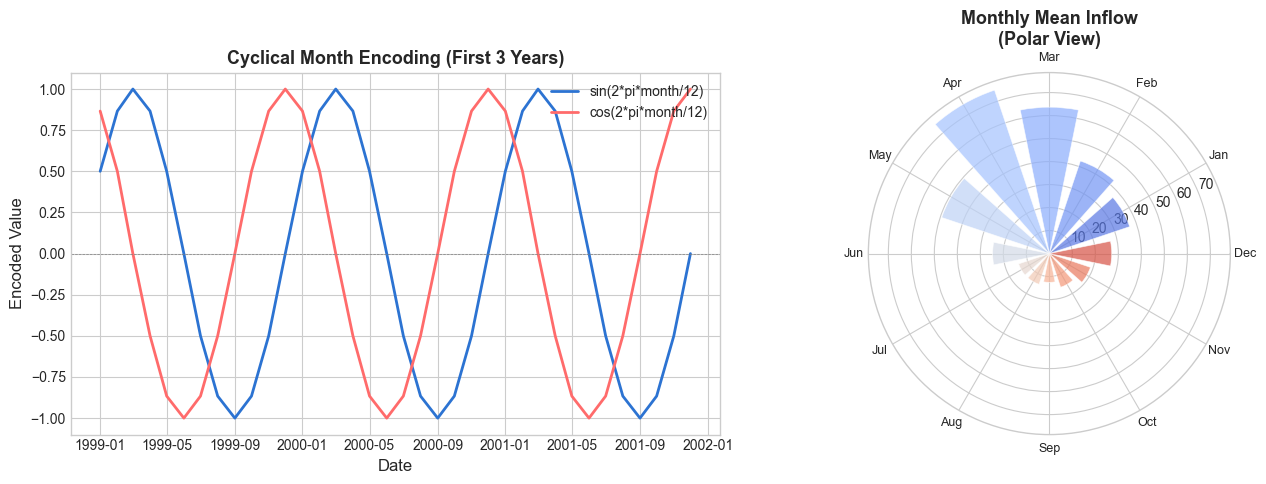

Cyclical encoding ensures that month 12 (December) is adjacent to month 1 (January) in feature space.
month_sin range: [-1.000, 1.000]
month_cos range: [-1.000, 1.000]


In [15]:
# 5.3 Seasonal (Cyclical) Encoding
df_feat['month_sin'] = np.sin(2 * np.pi * df_feat['Month'] / 12)
df_feat['month_cos'] = np.cos(2 * np.pi * df_feat['Month'] / 12)

# Visualize the encoding
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sin and Cos over time
axes[0].plot(df_feat.index[:36], df_feat['month_sin'].values[:36], 
             label='sin(2*pi*month/12)', color=PRIMARY_COLOR, linewidth=2)
axes[0].plot(df_feat.index[:36], df_feat['month_cos'].values[:36], 
             label='cos(2*pi*month/12)', color=SECONDARY_COLOR, linewidth=2)
axes[0].set_title('Cyclical Month Encoding (First 3 Years)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Encoded Value')
axes[0].legend()
axes[0].axhline(y=0, color='gray', linestyle='--', linewidth=0.5)

# Polar plot showing month positions
ax_polar = fig.add_subplot(122, projection='polar')
months = np.arange(1, 13)
theta = 2 * np.pi * months / 12
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_means = df.groupby('Month')['inflow'].mean()

bars = ax_polar.bar(theta, monthly_means.values, width=0.4, alpha=0.7,
                    color=plt.cm.coolwarm(np.linspace(0.1, 0.9, 12)),
                    edgecolor='white', linewidth=0.5)
ax_polar.set_xticks(theta)
ax_polar.set_xticklabels(month_labels, fontsize=9)
ax_polar.set_title('Monthly Mean Inflow\n(Polar View)', fontsize=13, fontweight='bold', pad=20)

# Remove the default subplot that was replaced by polar
axes[1].remove()

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}c2_seasonal_encoding.png', dpi=150, bbox_inches='tight')
plt.show()

print('Cyclical encoding ensures that month 12 (December) is adjacent to month 1 (January) in feature space.')
print(f'month_sin range: [{df_feat["month_sin"].min():.3f}, {df_feat["month_sin"].max():.3f}]')
print(f'month_cos range: [{df_feat["month_cos"].min():.3f}, {df_feat["month_cos"].max():.3f}]')

### 5.4 Trend Feature

A linear time index provides the model with a simple mechanism to capture long-term drift.

In [16]:
# 5.4 Trend Feature (linear time index)
df_feat['time_index'] = np.arange(len(df_feat))

# Normalized version (0 to 1) for better model convergence
df_feat['time_index_norm'] = df_feat['time_index'] / df_feat['time_index'].max()

print(f'Time index range: {df_feat["time_index"].min()} to {df_feat["time_index"].max()}')
print(f'Normalized time index range: {df_feat["time_index_norm"].min():.3f} to {df_feat["time_index_norm"].max():.3f}')

Time index range: 0 to 280
Normalized time index range: 0.000 to 1.000


### 5.5 Difference Features

Difference features capture momentum and seasonal changes:
- **Month-over-month change**: How much did inflow change from last month? Captures short-term momentum.
- **Year-over-year change**: How does this month compare to the same month last year? Captures inter-annual variability.

In [17]:
# 5.5 Difference Features
# Month-over-month change (using lagged values to prevent data leakage)
df_feat['diff_1'] = df_feat['inflow'].shift(1) - df_feat['inflow'].shift(2)  # change from t-2 to t-1
df_feat['diff_pct_1'] = df_feat['inflow'].shift(1).pct_change()  # percentage change at t-1

# Year-over-year change
df_feat['diff_12'] = df_feat['inflow'].shift(1) - df_feat['inflow'].shift(13)  # YoY change at t-1
df_feat['diff_pct_12'] = (df_feat['inflow'].shift(1) - df_feat['inflow'].shift(13)) / df_feat['inflow'].shift(13)  # YoY % change

print('Difference features created:')
print('  diff_1:      Month-over-month absolute change (lagged)')
print('  diff_pct_1:  Month-over-month percentage change (lagged)')
print('  diff_12:     Year-over-year absolute change (lagged)')
print('  diff_pct_12: Year-over-year percentage change (lagged)')

print(f'\nDifference feature preview (last 5 rows):')
df_feat[['inflow', 'diff_1', 'diff_pct_1', 'diff_12', 'diff_pct_12']].tail().round(3)

Difference features created:
  diff_1:      Month-over-month absolute change (lagged)
  diff_pct_1:  Month-over-month percentage change (lagged)
  diff_12:     Year-over-year absolute change (lagged)
  diff_pct_12: Year-over-year percentage change (lagged)

Difference feature preview (last 5 rows):


,inflow,diff_1,diff_pct_1,diff_12,diff_pct_12
Date,,,,,
2022-01-01,38.527,3.518,0.411,-1.581,-0.116
2022-02-01,55.861,26.450,2.190,4.980,0.148
2022-03-01,80.491,17.334,0.450,5.295,0.105
2022-04-01,64.485,24.630,0.441,23.368,0.409
2022-05-01,38.347,-16.006,-0.199,8.993,0.162


### 5.6 PACF-Based Feature Selection

We use the Partial Autocorrelation Function to objectively identify the most statistically significant lags. Only lags with PACF values exceeding the 95% confidence interval are considered important.

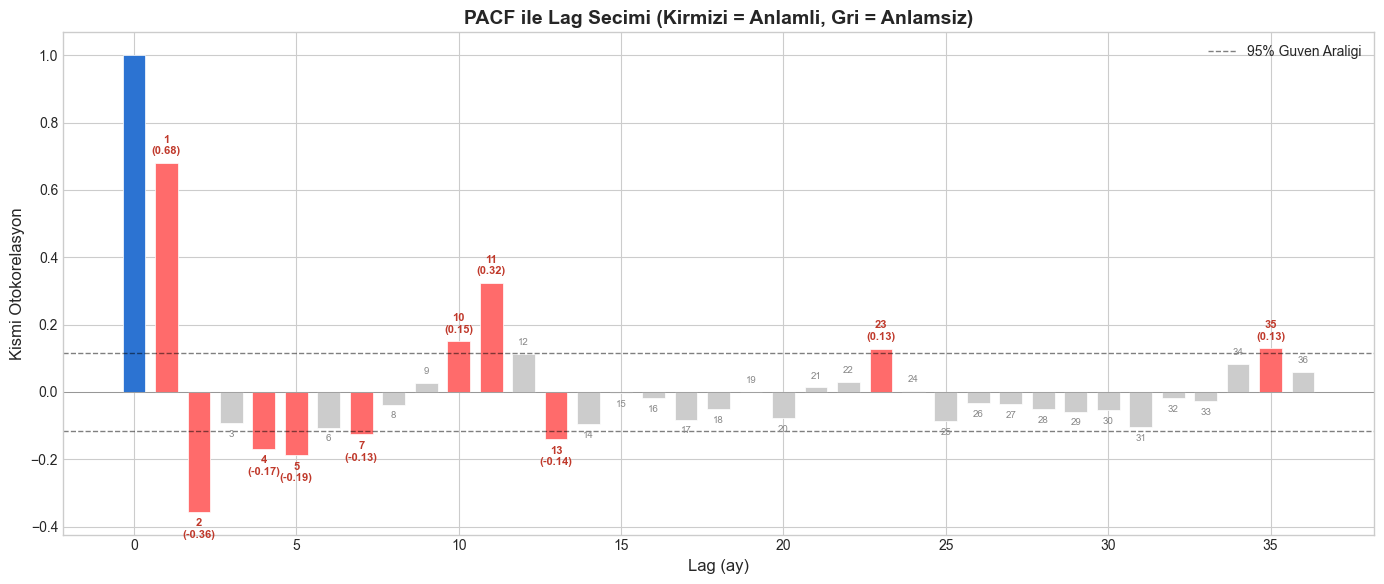

Significant lags (exceeding 95% CI): [1, 2, 4, 5, 7, 10, 11, 13, 23, 35]
Number of significant lags: 10

Top 5 most significant lags by absolute PACF value:
  Lag  1: PACF =  0.6802
  Lag  2: PACF = -0.3559
  Lag 11: PACF =  0.3231
  Lag  5: PACF = -0.1867
  Lag  4: PACF = -0.1684

These lags should be prioritized in the feature set for autoregressive models.


In [18]:
# 5.6 PACF-Based Feature Selection
n = len(df['inflow'])
max_lags = 36
pacf_values = pacf(df['inflow'], nlags=max_lags, method='ywm')

# 95% confidence interval
conf_interval = 1.96 / np.sqrt(n)

# Identify significant lags (excluding lag 0)
significant_lags = [i for i in range(1, max_lags + 1) if abs(pacf_values[i]) > conf_interval]

fig, ax = plt.subplots(figsize=(14, 6))

lags = np.arange(0, max_lags + 1)
colors = [SECONDARY_COLOR if i in significant_lags else '#CCCCCC' for i in lags]
colors[0] = PRIMARY_COLOR  # lag 0 is always 1.0

bars = ax.bar(lags, pacf_values, color=colors, edgecolor='white', linewidth=0.5, width=0.7)
ax.axhline(y=conf_interval, color='black', linestyle='--', linewidth=1, alpha=0.5, label='95% Guven Araligi')
ax.axhline(y=-conf_interval, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax.axhline(y=0, color='gray', linewidth=0.5)

ax.set_title('PACF ile Lag Secimi (Kirmizi = Anlamli, Gri = Anlamsiz)', fontsize=14, fontweight='bold')
ax.set_xlabel('Lag (ay)', fontsize=12)
ax.set_ylabel('Kismi Otokorelasyon', fontsize=12)
ax.legend(fontsize=10)

# Annotate each bar with lag number and value
for lag_i in range(1, max_lags + 1):
    val = pacf_values[lag_i]
    is_sig = lag_i in significant_lags

    if is_sig:
        label = f'{lag_i}\n({val:.2f})'
        fontsize = 8
        fw = 'bold'
        color = '#C0392B'
    else:
        label = str(lag_i)
        fontsize = 7
        fw = 'normal'
        color = '#888888'

    offset_y = 0.02 if val >= 0 else -0.02
    va = 'bottom' if val >= 0 else 'top'
    ax.text(lag_i, val + offset_y, label, ha='center', va=va,
            fontsize=fontsize, fontweight=fw, color=color)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}c2_pacf_feature_selection.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Significant lags (exceeding 95% CI): {significant_lags}')
print(f'Number of significant lags: {len(significant_lags)}')
print(f'\nTop 5 most significant lags by absolute PACF value:')
sorted_lags = sorted(significant_lags, key=lambda x: abs(pacf_values[x]), reverse=True)
for lag in sorted_lags[:5]:
    print(f'  Lag {lag:>2d}: PACF = {pacf_values[lag]:>7.4f}')

print(f'\nThese lags should be prioritized in the feature set for autoregressive models.')

---

## 6. Feature Overview and Correlation Analysis

In [19]:
# Complete feature overview
print(f'Total features engineered: {len(df_feat.columns) - 1} (excluding target)')
print(f'Total observations: {len(df_feat)}')
print(f'\nFeature list:')
print('-' * 60)
for i, col in enumerate(df_feat.columns):
    null_count = df_feat[col].isnull().sum()
    null_pct = null_count / len(df_feat) * 100
    print(f'  {i+1:>2d}. {col:<25s}  NaN: {null_count:>3d} ({null_pct:>5.1f}%)')

# After dropping NaN rows
df_feat_clean = df_feat.dropna()
print(f'\nRows after dropping NaN: {len(df_feat_clean)} (lost {len(df_feat) - len(df_feat_clean)} rows from lagging)')

Total features engineered: 28 (excluding target)
Total observations: 281

Feature list:
------------------------------------------------------------
   1. inflow                     NaN:   0 (  0.0%)
   2. Year                       NaN:   0 (  0.0%)
   3. Month                      NaN:   0 (  0.0%)
   4. lag_1                      NaN:   1 (  0.4%)
   5. lag_2                      NaN:   2 (  0.7%)
   6. lag_3                      NaN:   3 (  1.1%)
   7. lag_6                      NaN:   6 (  2.1%)
   8. lag_12                     NaN:  12 (  4.3%)
   9. lag_24                     NaN:  24 (  8.5%)
  10. rolling_mean_3             NaN:   3 (  1.1%)
  11. rolling_std_3              NaN:   3 (  1.1%)
  12. rolling_min_3              NaN:   3 (  1.1%)
  13. rolling_max_3              NaN:   3 (  1.1%)
  14. rolling_mean_6             NaN:   6 (  2.1%)
  15. rolling_std_6              NaN:   6 (  2.1%)
  16. rolling_min_6              NaN:   6 (  2.1%)
  17. rolling_max_6              Na

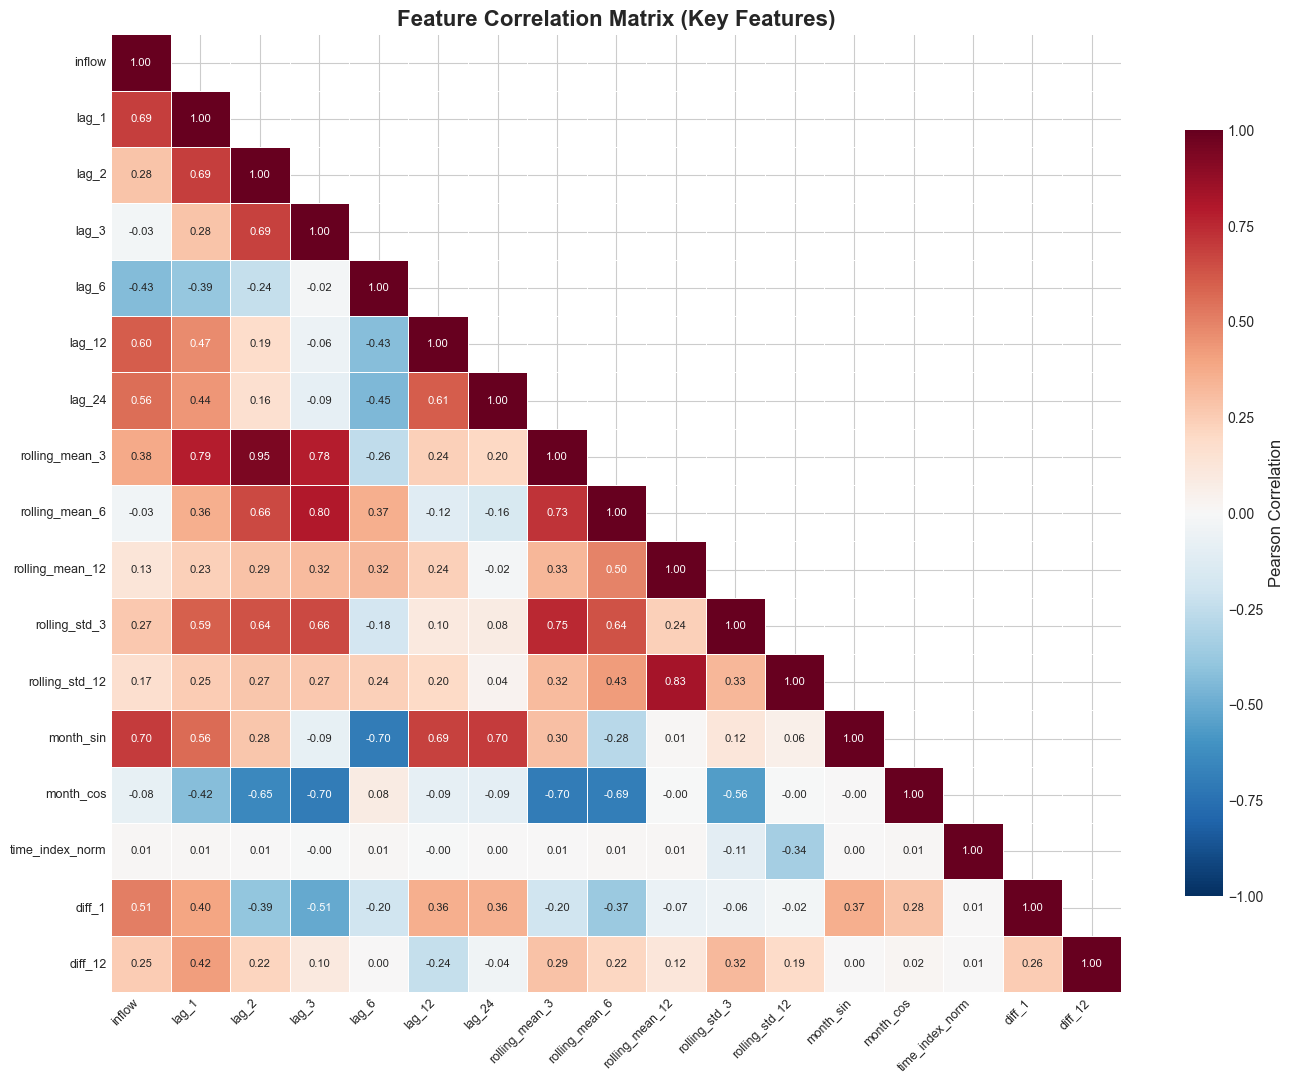

Feature correlations with target (inflow):
---------------------------------------------
  month_sin                0.699  +++++++++++++++++++++
  lag_1                    0.688  +++++++++++++++++++++
  lag_12                   0.602  +++++++++++++++++++
  lag_24                   0.557  +++++++++++++++++
  diff_1                   0.515  ++++++++++++++++
  rolling_mean_3           0.376  ++++++++++++
  lag_2                    0.283  +++++++++
  rolling_std_3            0.272  +++++++++
  diff_12                  0.254  ++++++++
  rolling_std_12           0.166  +++++
  rolling_mean_12          0.131  ++++
  time_index_norm          0.009  +
  lag_3                   -0.027  -
  rolling_mean_6          -0.032  -
  month_cos               -0.082  -++
  lag_6                   -0.434  -+++++++++++++


In [20]:
# Feature Correlation Heatmap
# Select key features for readability
key_features = ['inflow', 'lag_1', 'lag_2', 'lag_3', 'lag_6', 'lag_12', 'lag_24',
                'rolling_mean_3', 'rolling_mean_6', 'rolling_mean_12',
                'rolling_std_3', 'rolling_std_12',
                'month_sin', 'month_cos', 'time_index_norm',
                'diff_1', 'diff_12']

# Filter to only existing columns
key_features = [f for f in key_features if f in df_feat_clean.columns]

corr_matrix = df_feat_clean[key_features].corr()

fig, ax = plt.subplots(figsize=(14, 11))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1,
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Pearson Correlation', 'shrink': 0.8},
            ax=ax, annot_kws={'size': 8})

ax.set_title('Feature Correlation Matrix (Key Features)', fontsize=16, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}c2_feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

# Print top correlations with target
target_corr = corr_matrix['inflow'].drop('inflow').sort_values(ascending=False)
print('Feature correlations with target (inflow):')
print('-' * 45)
for feat, corr_val in target_corr.items():
    bar = '+' * int(abs(corr_val) * 30)
    sign = '+' if corr_val > 0 else '-'
    print(f'  {feat:<22s}  {corr_val:>6.3f}  {sign}{bar}')

In [21]:
# Save engineered features DataFrame
output_path = '../data/'
os.makedirs(output_path, exist_ok=True)

# Save full dataset (with NaN)
df_feat.to_csv(f'{output_path}features_all.csv')
print(f'Full feature dataset saved to: {output_path}features_all.csv')
print(f'  Shape: {df_feat.shape}')

# Save clean dataset (NaN dropped)
df_feat_clean.to_csv(f'{output_path}features_clean.csv')
print(f'\nClean feature dataset saved to: {output_path}features_clean.csv')
print(f'  Shape: {df_feat_clean.shape}')
print(f'  Date range: {df_feat_clean.index.min().strftime("%Y-%m")} to {df_feat_clean.index.max().strftime("%Y-%m")}')

print(f'\nFinal feature count: {len(df_feat_clean.columns)} columns '
      f'({len(df_feat_clean.columns) - 3} features + target + Year + Month)')

Full feature dataset saved to: ../data/features_all.csv
  Shape: (281, 29)

Clean feature dataset saved to: ../data/features_clean.csv
  Shape: (257, 29)
  Date range: 2001-01 to 2022-05

Final feature count: 29 columns (26 features + target + Year + Month)


---

## 7. Summary of Key Findings

### Data Characteristics

1. **Strong Seasonality**: 12-month cycle with peaks in **March-April** (snowmelt) and troughs in **July-September** (dry season).
2. **Moderate Trend**: Slight long-term trend, but inter-annual variability dominates.
3. **Right-Skewed Distribution**: Occasional extreme peaks; log transformation improves normality.

### Autocorrelation Structure

4. **Key Lags**: PACF identifies lag 1 and lag 12 as consistently significant.
5. **Seasonal Memory**: ACF shows slowly decaying sinusoidal pattern with peaks at multiples of 12.

### Feature Engineering

6. **30+ features** across six categories: lags, rolling statistics, cyclical encoding, trend, differences, PACF-selected.
7. **Data Leakage Prevention**: All features use shifted (lagged) values. Rolling statistics computed on shifted series.
8. **Multicollinearity**: Handled naturally by tree-based methods (XGBoost) and regularized models (Ridge).